# Few-Shot-Learning for Maize yield prediction in Ghana

In [ ]:
!pip install git+https://github.com/ScaleAGData/scaleag-vito.git@prometheo-integration --quiet

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.openeo.extract_sample_scaleag import generate_input_for_extractions, extract
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import finetune_on_task, load_finetuned_model, evaluate_finetuned_model, get_pretrained_model_url
from scaleagdata_vito.presto.inference import PrestoPredictor, reshape_result, plot_results
from scaleagdata_vito.utils.map import ui_map
from scaleagdata_vito.utils.dateslider import date_slider
from scaleagdata_vito.openeo.extract_sample_scaleag import collect_inputs_for_inference

### Before we start...

**Check your data!** Investigate validity of geometries uniqueness of sample IDs, presence of outliers and so on before starting the extraction. Achieving good performance making use of a limited amount of data is a challening task per se. Therefore, **the quality of your data will greatly impact your final results.**

Data requirements:
- Points or Polygons (will be aggregated in points)
- Lat-Lon (crs:4326) 
- Format: parquet, GeoJSON, shapefile, GPKG
For each geometry:
- Date (if available) 
- Unique ID
- Annotations

Good practice:

Remove polygons close to borders (e.g. apply buffer) to ensure data are contained in the field
If the annotations are accurate, point geometries should be preferred. However, especially in regression tasks (i.e., continuous output values) such us yield estimation the target values might be noisy. In that case, we recommend subdividing the polygons in subfields of 20m x 20m (to cover more measurements) and computing the median yield for a smoother and more reliable target

##### Assess data correctness before launching the OpenEO jobs 
You can run some checks on your input file to make sure they are suitable to run the extractions successfully. In particular, it is important to check the validity of the geometries and, to also have a column containing a unique id for each sample. Do these checks beforehand by running the first section of the notebook `data_investigation.ipynb`

##### Requirements for running the extractions
- Account in [Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/). You can sign up for free and have a monthly availability of 10000 credits.
- A dataset with valid geometries (Points or Polygons) in lat-lon projection.
- Preferably a dataset with unique IDs per sample 
- A labelled dataset. Not required for the extraction process, but for the following fine-tuning steps.

##### EO data extractions
In this first step, we extract for each sample in your dataset the required EO time series from CDSE using OpenEO.
For running the job, the user should indicate the following job_dictionary fields:

```python
    job_params = dict(
        output_folder=..., # where to save the extracted dataset
        input_df=..., # input georeferenced dataset to run the extractions for 
        start_date=..., # string indicating from which date to extract data  
        end_date=..., # string indicating until which date to extract the data 
        unique_id_column=..., # name of the column in the input_df containing the unique ID of the samples  
        composite_window=..., # "month" or "dekad" are supported. Default is "dekad"
    )
```
in particular:
- If the `date` information associated with the label is provided, the `start_date` of the time-series is automatically set to 9 months before the date, whereas the `end_date` is set to 9 months after. If `date` is not available, the user needs to manually indicate the desired `start_date` and `end_date` for the extractions. **The indicated period should cover 1 year**. 
- `composite_window` indicates the time-series granularity, which can be dekadal or monthly. 
  - `dekad`: each time step in the extracted time series corresponds to a mean-compositing operation on 10-days acquisitions. Accordingly with the start and end date, each month will be covered by 3 time steps which, by default, correspond to the 1st, 11th and 21th of the month. 
  - `month`: each time step in the extracted time series corresponds to a mean-compositing operation on 30-days acquisitions. Each month will be covered by 1 time step which, by default, correspond to the 1st of the month.

The following decadal/monthly time series will be extracted for the indicated time range:

- Sentinel-2 L2A data (all bands)
- Sentinel-1 VH and VV
- Average air temperature and precipitation sum derived from AgERA5
- Slope and elevation from Copernicus DEM

Presto accepts 1D time-series. Therefore, if Polygons are provided for the extractions, the latter are spatially aggregated in points which will correspond to the centroid lat lon geolocation.

### 1) Run extractions

In [9]:
# Dataset Parameters
start_date="..."
end_date="..."
composite_window="month"
unique_id_column="Field_ID"
input_df="..."
output_folder=f"..."

In [ ]:
job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)
extract(generate_input_for_extractions(job_params))

Once the dataset will be extracted, it can be loaded with the `load_dataset` function by specifying the path where the `.parquet` files have been downloaded. Moreover, **if** we are dealing with 1 year of data falling in the **same time period**, the following manipulations of the dataset are also possible.

- `window_of_interest`: the user can specify a time window of interest out of the whole available time-series. `start_date` and `end_date` should be provided as strings in a list.
- `use_valid_time`: the user might want to define the window of interest based on the `date` the label is associated with. If so, also `required_min_timesteps` should be provided
- `buffer_window`: buffers the `start_date` and `end_date` by a number of time steps specified with this argument. 

In the following cell, we load the extracted dataset for 1 year of data.

### 2) Presto datasets initialization

In [10]:
data_folder = Path.cwd().parent / "data/extractions/month"
composite_window = "month"
unique_id_column = "Field_ID"
target_name = 'Yield kg/H'

In [11]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2021-07-01", "2021-11-30"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2022-07-01", "2022-11-30"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2023-07-01", "2023-11-30"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2025-07-01", "2025-11-30"],
)
extraction_tuples = list(zip([extractions_2021, extractions_2022, extractions_2023, extractions_2025], [2021, 2022, 2023, 2025]))

  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/

#### Data investigation

In [12]:
# Specific for data used in this notebook
def correct_extractions(extractions):
    extraction_all = pd.DataFrame()
    for extraction, year in extractions:
        if year == 2022:
            extraction = extraction[extraction['Yield kg/H'] != 65535].reset_index(drop=True)
        extraction['year'] = year
        extraction["Field_ID"] = extraction['Field_ID'] + "_" + extraction['year'].astype(str)
        extraction['REGION'] = extraction['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
        extraction['DISTRICT'] = extraction['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
        extraction['COMMUNITY'] = extraction['COMMUNITY'].apply(lambda x: x.upper())
        extraction_all = pd.concat([extraction_all, extraction], ignore_index=True)
    return extraction_all

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram with bars next to each other
    bin_edges = np.histogram_bin_edges(
        pd.concat([train_df[target_column], test_df[target_column], val_df[target_column]]).dropna(), bins=20
    )

    width = 0.25
    # Plot histogram for Yield kg/H for each split using the same bin edges
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        hist, _ = np.histogram(data[target_column].dropna(), bins=bin_edges)
        # Use bin centers for bar positions
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        axes[0, 2].bar(bin_centers + i*width - width, hist, width=width, alpha=0.7, color=color, label=label, align='center')
        # x_ticks = [bin_centers + i*width]
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    # axes[0, 2].set_xticks(x_ticks)
    axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Bin mean yield and std plot
    bin_labels = ['Low', 'High'] if 'bin' in train_df.columns else train_df['bin'].unique().astype(str)
    x = np.arange(len(bin_labels))
    for idx, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        bin_means = data.groupby('bin')['Yield kg/H'].mean().reindex([0,1], fill_value=0)
        bin_stds = data.groupby('bin')['Yield kg/H'].std().reindex([0,1], fill_value=0)
        axes[1, 2].bar(x + idx*width, bin_means.values, width=width, yerr=bin_stds.values, capsize=5, color=color, alpha=0.8, label=label)

    axes[1, 2].set_title('Bin Mean Yield ± Std')
    axes[1, 2].set_xlabel('Bin')
    axes[1, 2].set_ylabel('Mean Yield (kg/H)')
    axes[1, 2].set_xticks(x + width)
    axes[1, 2].set_xticklabels(bin_labels)
    axes[1, 2].legend()
    # # Remove the empty subplot
    # axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

In [13]:
extractions = correct_extractions(extraction_tuples)

we divide the data in High and Low yield classes by taking the setting the threshold on the peak of the global data distribution

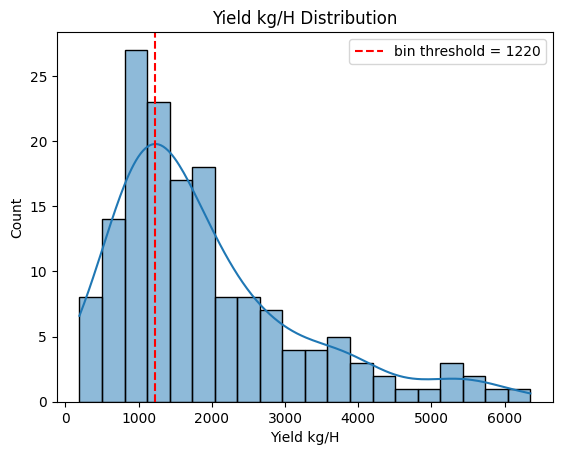

In [14]:
bin_th = 1220
sns.histplot(extractions['Yield kg/H'], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()

we now binarize the target and divide our data making sure the proportion of low and high yield data are represented in all the splits

In [15]:
from sklearn.model_selection import train_test_split

def binarize_target_and_split_data(extractions, target_column, unique_id_column, bin_th):
    # Create bins for stratification based on the parent group's median yield
    extractions['bin'] = extractions[target_column].apply(lambda x: 0 if x < bin_th else 1)

    # Filter out yield bins with less than 3 samples to avoid stratification issues
    bin_counts = extractions['bin'].value_counts()
    valid_bins = bin_counts[bin_counts >= 3].index
    extractions_filtered = extractions[extractions['bin'].isin(valid_bins)]

    # Compute mean and std of yield for each bin and add as columns
    bin_stats = extractions_filtered.groupby('bin')[target_column].agg(['mean', 'std']).rename(columns={'mean': 'bin_mean_yield', 'std': 'bin_std_yield'})
    extractions_filtered = extractions_filtered.merge(bin_stats, left_on='bin', right_index=True, how='left')

    print(f"Original parent groups: {len(extractions)}")
    print(f"After filtering bins with <3 samples: {len(extractions_filtered)}")
    print(f"Removed {len(extractions) - len(extractions_filtered)} parent groups")

    # Get unique parentnames as our splitting units (from filtered data)
    parentnames = extractions_filtered[unique_id_column].unique().tolist()
    yield_bins = extractions_filtered['bin'].values

    # First split: 80% train, 20% temp (for val and test)
    train_parents, temp_parents = train_test_split(
        parentnames,
        train_size=0.8,
        stratify=yield_bins,
        random_state=42
    )

    # Get yield bins for temp parents and check if they still have enough samples for stratification
    temp_bins = extractions_filtered[extractions_filtered[unique_id_column].isin(temp_parents)]['bin'].values
    temp_bin_counts = pd.Series(temp_bins).value_counts()

    # Check if any bin in temp set has less than 2 samples (minimum for stratification)
    if (temp_bin_counts < 2).any():
        print("Warning: Some bins in temp set have <2 samples. Using random split instead of stratified split for val/test.")
        # Second split: split temp randomly into 50-50 for val and test
        val_parents, test_parents = train_test_split(
            temp_parents,
            train_size=0.5,
            random_state=42
        )
    else:
        # Second split: split temp into 50-50 for val and test with stratification
        val_parents, test_parents = train_test_split(
            temp_parents,
            train_size=0.5,
            stratify=temp_bins,
            random_state=42
        )

    # Create the final datasets by filtering on parentname
    train_df = extractions_filtered[extractions_filtered[unique_id_column].isin(train_parents)]
    val_df = extractions_filtered[extractions_filtered[unique_id_column].isin(val_parents)]
    test_df = extractions_filtered[extractions_filtered[unique_id_column].isin(test_parents)]

    print(f"Train set size: {len(train_df)} ({len(train_df)/len(extractions_filtered)*100:.1f}%)")
    print(f"Validation set size: {len(val_df)} ({len(val_df)/len(extractions_filtered)*100:.1f}%)")
    print(f"Test set size: {len(test_df)} ({len(test_df)/len(extractions_filtered)*100:.1f}%)")

    # Verify no parentname overlap
    assert len(set(train_df[unique_id_column]) & set(val_df[unique_id_column])) == 0
    assert len(set(train_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
    assert len(set(val_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
    print(f"✓ No {unique_id_column} overlap between splits")
    return train_df, val_df, test_df

train_df, val_df, test_df = binarize_target_and_split_data(extractions, target_name, unique_id_column, bin_th)

Original parent groups: 157
After filtering bins with <3 samples: 157
Removed 0 parent groups
Train set size: 125 (79.6%)
Validation set size: 16 (10.2%)
Test set size: 16 (10.2%)
✓ No Field_ID overlap between splits


/tmp/ipykernel_751791/2959583095.py:89: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])


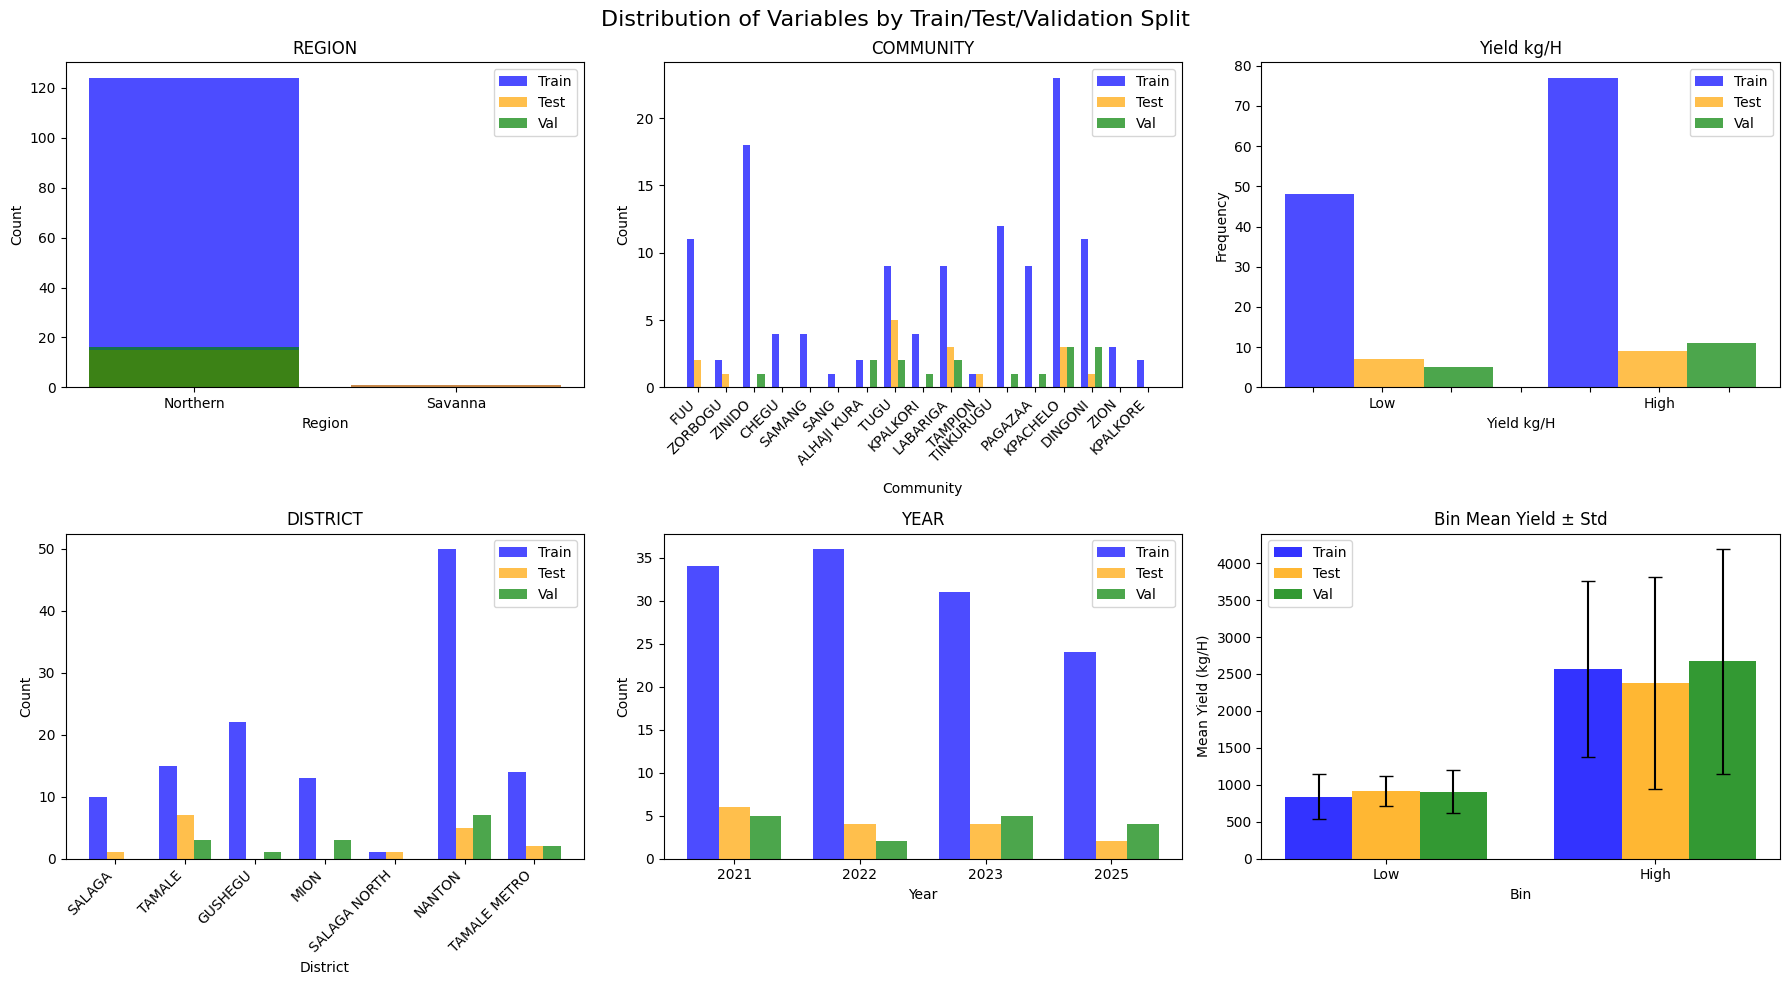

In [16]:
plot_distribution(train_df, test_df, val_df, 'bin')

We Initialize the training, validation and test datasets objects to be used for training Presto.

In [17]:
target_name = "bin"
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "binary"

In [18]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

### 3) Presto Finetuning

In this section Presto will be Fine-Tuned in a supervised way for the target downstream task. first we set up the following experiment parameters:

- `output_dir` : where to dave the model 
- `experiment_name` : the model name

In [ ]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("./models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize-bin-patience=epochs"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32 
num_workers = 0
max_epochs = 100  # Keep reasonable number of epochs
patience = 100  # More patience for convergence
# freeze_layers = ['encoder']
# unfreeze_epoch = 200  # Keep early unfreezing

In [37]:
from scaleagdata_vito.presto.utils import get_pretrained_model_url

loss_fn = nn.BCEWithLogitsLoss()


pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
# scheduler_plateau = lr_scheduler.ReduceLROnPlateau(optimizer, factor=drop_factor, min_lr=end_lr)
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    # freeze_layers=freeze_layers,
    # unfreeze_epoch=unfreeze_epoch,
)

2026-03-12 16:16:53.040 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/git/GEOMaize/notebooks/models/presto-scaleag-ft-month-geomaize-bin-patience=epochs


Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-12 16:16:53.522 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 0.7097 | Val Loss: 0.6264 | Best Loss: 0.6264 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-03-12 16:18:19.579 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 198/200: Epoch 198/200 | Train Loss: 0.2020 | Val Loss: 1.0861 | Best Loss: 0.2517 (no improvement for 101 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-12 16:18:19.839 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 199/200: Epoch 199/200 | Train Loss: 0.1606 | Val Loss: 1.0614 | Best Loss: 0.2517 (no improvement for 102 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-12 16:18:20.092 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 200/200: Epoch 200/200 | Train Loss: 0.1524 | Val Loss: 0.8265 | Best Loss: 0.2517 (no improvement for 103 epochs)
2026-03-12 16:18:20.199 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [38]:
# Get predictions for train and validation sets as well
train_metrics, train_preds_presto, train_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds_presto, val_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

test_metrics, test_preds_presto, test_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

2026-03-12 16:18:29.261 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-03-12 16:18:29.422 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-03-12 16:18:29.461 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task


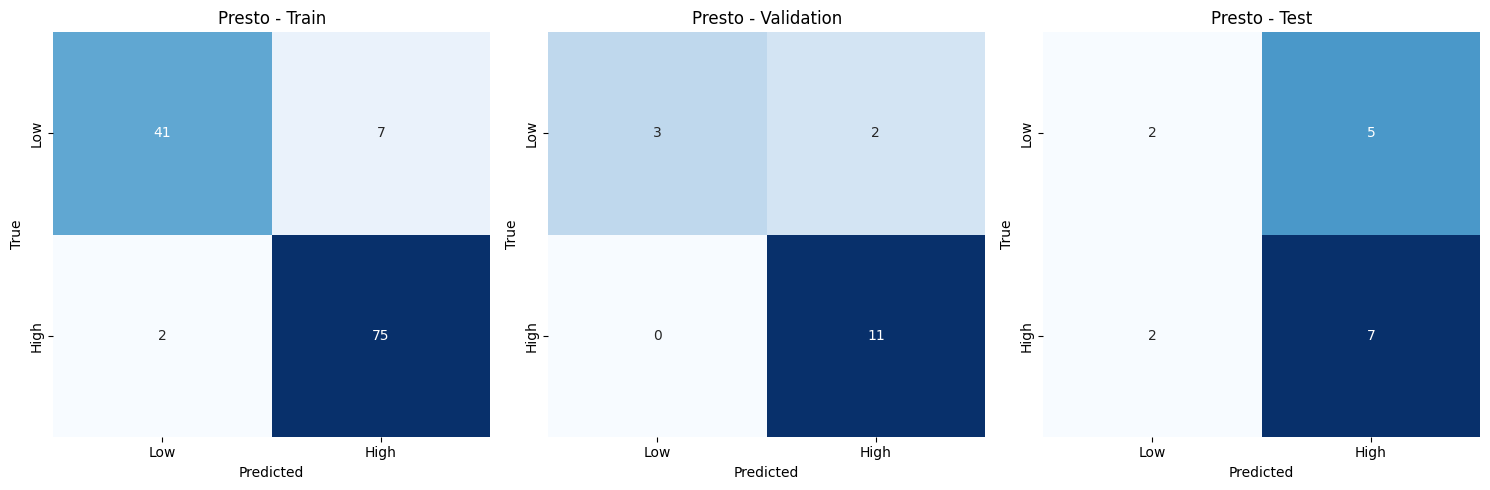

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare predictions and true labels for each model and split
model_name = "Presto"
split_names = ["Train", "Validation", "Test"]
model_preds = [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)]
model_trues = [train_targets_presto, val_targets_presto, test_targets_presto]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, split_name in enumerate(split_names):
    y_true = model_trues[col]
    y_pred = model_preds[col]
    # Convert boolean to int if needed
    if y_pred.dtype == bool:
        y_pred = y_pred.astype(int)
    if y_true.dtype == bool:
        y_true = y_true.astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[col], cbar=False,
                xticklabels=["Low", "High"], yticklabels=["Low", "High"])
    axes[col].set_xlabel('Predicted')
    axes[col].set_ylabel('True')
    axes[col].set_title(f"{model_name} - {split_name}")

plt.tight_layout()
plt.show()

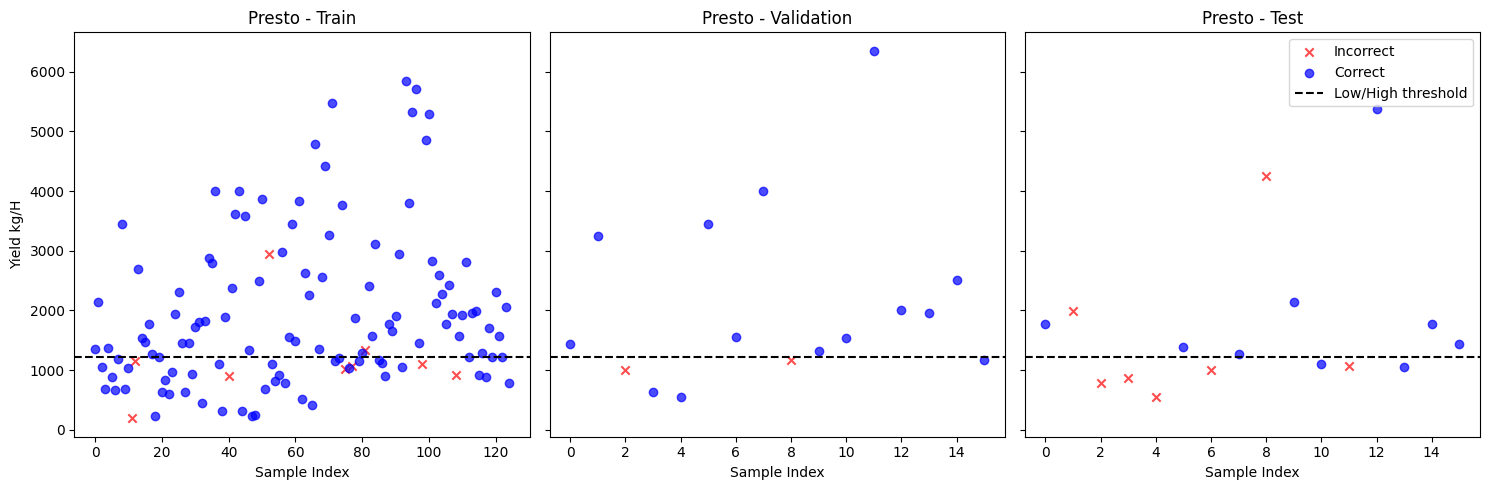

In [40]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = [
    (
        "Presto",
        [train_targets_presto, val_targets_presto, test_targets_presto],
        [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
]

col_titles = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=True)

for row, (model_name, y_trues, y_preds, yields) in enumerate(plot_data):
    for col in range(3):
        ax = axes[col]
        y_true = y_trues[col]
        y_pred = y_preds[col]
        yield_vals = yields[col]
        correct = (y_true == y_pred)
        # Plot correct in blue, incorrect in red
        ax.scatter(
            np.arange(len(yield_vals))[~correct], yield_vals[~correct], 
            c="red", label="Incorrect", alpha=0.7, marker="x"
        )
        ax.scatter(
            np.arange(len(yield_vals))[correct], yield_vals[correct], 
            c="blue", label="Correct", alpha=0.7, marker="o"
        )
        # Draw the bin threshold line and always show its label in the legend
        ax.axhline(bin_th, color="black", linestyle="--", label="Low/High threshold")
        ax.set_title(f"{model_name} - {col_titles[col]}")
        ax.set_xlabel("Sample Index")
        if col == 0:
            ax.set_ylabel("Yield kg/H")
        if row == 0 and col == 2:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 4) Inference using Fine-Tuned end-to-end Presto

In this section, we apply the fine tuned model to generate a yield map on an unseen area. 
We need to indicate the spatial and temporal extent. The 2 cells below, offer a simple way for the user to provide these information and perform once again the extraction from CDSE of the EO time-series required by Presto. 
We also need to indicate the `output_dir` of where to save the datacube of the extraction, its `output_filename` and the `composite_window` which will be the same as used for finetuning the model.

In [ ]:
map = ui_map(area_limit=7)

In [ ]:
# select 1 year of data
slider = date_slider()

In [ ]:
output_dir = Path("/home/giorgia/Private/data/geomaize/regression")
output_filename = "inference_area"
inference_file = output_dir / f"{output_filename}.nc"

In [ ]:
collect_inputs_for_inference(
    spatial_extent=map.get_extent(),
    temporal_extent=slider.get_processing_period(),
    output_path=output_dir,
    output_filename=f"{output_filename}.nc",
    composite_window=composite_window,
)

Once the datacube has been extracted, we can perform the inference task using the finetuned model and visualize the predicted map. 

In [ ]:
inference_file = output_dir / "inference_area.nc"
mask_path = None

In [ ]:
finetuned_model = load_finetuned_model(model_output_dir / experiment_name, task_type=task_type)
presto_model = PrestoPredictor(
    model=finetuned_model,
    batch_size=50,
    task_type=task_type,
    composite_window=composite_window,
)

predictions = presto_model.predict(
    inference_file, 
    mask_path=mask_path,
    )
predictions_map = reshape_result(predictions, path_to_input_file=inference_file)

In [ ]:
plot_results(prob_map=predictions_map, path_to_input_file=inference_file, task=task_type, ts_index=16)